In [1]:
import pandas as pd
import numpy as np
from numpy import matmul
from scipy import stats
from sklearn import metrics
from numpy.linalg import inv
import random
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif, SelectKBest, chi2
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, cumulative_dynamic_auc
from itertools import chain
import seaborn as sns


In [2]:
def Filter(string, substr):
    return [str for str in string if
             any(sub in str for sub in substr)]

def vectorized_gaussian_logpdf(X, means, covariances):
    # """
    # Compute log N(x_i; mu_i, sigma_i) for each x_i, mu_i, sigma_i
    # Args:
    #     X : shape (d)
    #         Data points
    #     means : shape (self.N, d)
    #         Mean vectors
    #     covariances : shape (self.N, d)
    #         Diagonal covariance matrices
    # Returns:
    #     logpdfs : shape (n,)
    #         Log probabilities
    # """
        d = X.shape[0]
        constant = d * np.log(2 * np.pi)
        log_determinants = np.log(np.prod(covariances, axis=1))
        deviations = X - means
        inverses = 1 / covariances
        return -0.5 * (constant + log_determinants + np.sum(deviations * inverses * deviations, axis=1))

def vectorized_norm_loglikelihood(X, means, covariances, delta):
    #  '''
    #  Compute log Norm(X_i, mu_i, sigma_i) for each x_i, mu_i, sigma_i
    #  Args:
    #      X: shape (n,)
    #      means: shape (n,d)
    #      covariances (d,)
    #  Returns: logsf: shape (d,)
    #  '''
    loglikelihood = [delta*np.log(stats.norm.pdf(x = X, loc=means[:, i], scale=np.sqrt(covariances[i]))) + (1-delta)*np.log(stats.norm.sf(x = X, loc=means[:, i], scale=np.sqrt(covariances[i]))) for i in range(means.shape[1])]
    loglikelihood = np.array(loglikelihood).sum(axis=1)
    return loglikelihood

In [3]:
IND_TRAIN = [[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15],
             [0,1,2,3,4,5,6,7,8,9,10,11,16,17,18,19],
             [0,1,2,3,4,5,6,7,12,13,14,15,16,17,18,19],
             [0,1,2,3,8,9,10,11,12,13,14,15,16,17,18,19],
             [4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19]]
IND_TEST = [[16,17,18,19],
            [12,13,14,15],
            [8,9,10,11],
            [4,5,6,7],
            [0,1,2,3]]

In [4]:
Z_Y = []
Z_X = []
BETA_Y = []
TAU_Y = []
BETA_X = []
TAU_X = []
data_train = []
ind_train = IND_TRAIN[0]
ind_test = IND_TEST[0]
for i in ind_train:
    dat = pd.read_csv(f'Simulation_7_cluster_subset_{i+1}.csv', index_col=0)
    z_y = pd.read_csv(f'{i+1}/Simulation 7_{i+1}_Z_Y_records.csv', index_col=0)
    z_x = pd.read_csv(f'{i+1}/Simulation 7_{i+1}_Z_X_records.csv', index_col=0)
    beta_y = pd.read_csv(f'{i+1}/Simulation 7_{i+1}_BETA_Y_records.csv', index_col=0)
    tau_y = pd.read_csv(f'{i+1}/Simulation 7_{i+1}_TAU_Y_records.csv', index_col=0)
    beta_x = pd.read_csv(f'{i+1}/Simulation 7_{i+1}_BETA_X_records.csv', index_col=0)
    tau_x = pd.read_csv(f'{i+1}/Simulation 7_{i+1}_TAU_X_records.csv', index_col=0)
    Z_Y.append(z_y)
    Z_X.append(z_x)
    BETA_Y.append(beta_y)
    TAU_Y.append(tau_y)
    BETA_X.append(beta_x)
    TAU_X.append(tau_x)
    data_train.append(dat)


In [5]:
data_test=[]
for i in ind_test:
    dat = pd.read_csv(f'Simulation_7_cluster_subset_{i+1}.csv', index_col=0)
    data_test.append(dat)

In [6]:
Training = pd.concat(data_train, ignore_index=True)
Training['y'] = np.log(Training['y'])
true_train_z_y = Training['Z']
true_train_y = Training['y']
true_train_sf = Training['true_sf']
Testing = pd.concat(data_test, ignore_index=True)
Testing['y'] = np.log(Testing['y'])
true_test_z_y = Testing['Z']
true_test_y = Testing['y']
true_test_sf = Testing['true_sf']
delta_test = Testing['C']
Testing1 = Testing.drop(columns=['Z', 'C', 'y','true_sf'])
X_name = Testing1.columns

In [7]:
n_subsets_cluster_y = [[Z_Y[j].iloc[:,i].nunique() for j in range(16)] for i in range(50)]
# print(n_subsets_cluster_y, n_subsets_cluster_y[0])
n_subsets_cluster_x = [[Z_X[j].iloc[:,i].nunique() for j in range(16)] for i in range(50)]
random.seed(10)
reference_subset = random.choices(range(16),k=50)

In [8]:
Agg_z_y = [Z_Y[i].copy() for i in range(16)]
Agg_z_x = [Z_X[i].copy() for i in range(16)]

for t in range(50):
    i = reference_subset[t]
    # print(i)
    target_z_y = Z_Y[i].iloc[:,t]
    n_N_y = target_z_y.value_counts(sort=False).sort_index()
    target_z_x = Z_X[i].iloc[:,t]
    beta_y = BETA_Y[i]
    name_beta_y = Filter(beta_y.columns, [f'in_{t+1}_iteration'])
    target_beta_y = beta_y[name_beta_y].values
    tau_y = TAU_Y[i]
    name_tau_y = Filter(tau_y.columns, [f'in_{t+1}_iteration'])
    target_tau_y = tau_y[name_tau_y].values
    beta_x = BETA_X[i]
    name_beta_x = Filter(beta_x.columns, [f'in_{t+1}_iteration'])
    target_beta_x = beta_x[name_beta_x].values
    tau_x = TAU_X[i]
    name_tau_x = Filter(tau_x.columns, [f'in_{t+1}_iteration'])
    target_tau_x = tau_x[name_tau_x].values
    for k in range(16):
        n_n = n_subsets_cluster_y[t][k]
        # print(f'the {k+1}th subset in the {t+1}th iteration')
        if k != i:
            DAT = data_train[k]
            for s in range(n_n):
                ddd = DAT[Z_Y[k][f'z_y_{t+1}_iteration'] == s]
                # print(ddd.shape)
                X = ddd[X_name].values
                delta = ddd['C'].values
                y = np.log(ddd['y'].values)
                # print(y.shape)
                mean_y = matmul(X, target_beta_y)
                # print(mean_y)
                likelihood_y = vectorized_norm_loglikelihood(y, mean_y, target_tau_y[0], delta)
                # print(likelihood_y)
                # print(likelihood_y)
                likelihood_y = np.nan_to_num(likelihood_y, nan=-np.inf)
                # likelihood_x = [np.exp(vectorized_gaussian_logpdf(X[t], target_beta_x.T, target_tau_x.T)) for t in range(X.shape[0])]
                # likelihood_x = np.array(likelihood_x).sum(axis=0)
                true_z_y = np.argmax(likelihood_y)
                
                # true_z_x = np.argmax(likelihood_x)
                Agg_z_y[k].loc[ddd.index, f'z_y_{t+1}_iteration'] = true_z_y
                # Agg_z_x[k].loc[ddd.index, f'z_x_{t+1}_iteration'] = true_z_x


C:\Users\ndong\AppData\Local\Temp\ipykernel_22884\1112869675.py:35: RuntimeWarning: divide by zero encountered in log
  loglikelihood = [delta*np.log(stats.norm.pdf(x = X, loc=means[:, i], scale=np.sqrt(covariances[i]))) + (1-delta)*np.log(stats.norm.sf(x = X, loc=means[:, i], scale=np.sqrt(covariances[i]))) for i in range(means.shape[1])]
C:\Users\ndong\AppData\Local\Temp\ipykernel_22884\1112869675.py:35: RuntimeWarning: invalid value encountered in multiply
  loglikelihood = [delta*np.log(stats.norm.pdf(x = X, loc=means[:, i], scale=np.sqrt(covariances[i]))) + (1-delta)*np.log(stats.norm.sf(x = X, loc=means[:, i], scale=np.sqrt(covariances[i]))) for i in range(means.shape[1])]
C:\Users\ndong\AppData\Local\Temp\ipykernel_22884\1112869675.py:35: RuntimeWarning: divide by zero encountered in log
  loglikelihood = [delta*np.log(stats.norm.pdf(x = X, loc=means[:, i], scale=np.sqrt(covariances[i]))) + (1-delta)*np.log(stats.norm.sf(x = X, loc=means[:, i], scale=np.sqrt(covariances[i]))) fo

In [9]:
train_RI = []
train_MI = []
train_ARI = []
train_AMI = []
train_HOMO = []
train_COM = []
train_VM = []
train_FM = []
AGG_Z_Y = pd.concat(Agg_z_y, ignore_index=True)
# AGG_Z_Y.to_csv('''train_z_y_cluster_agg.csv''')
# print(AGG_Z_Y)
for j in range(AGG_Z_Y.shape[1]):
    ri = metrics.rand_score(true_train_z_y, AGG_Z_Y.iloc[:,j])
    mi = metrics.mutual_info_score(true_train_z_y, AGG_Z_Y.iloc[:,j])
    ari = metrics.adjusted_rand_score(true_train_z_y,AGG_Z_Y.iloc[:,j])
    ami = metrics.adjusted_mutual_info_score(true_train_z_y, AGG_Z_Y.iloc[:,j])
    hcv = metrics.homogeneity_completeness_v_measure(true_train_z_y, AGG_Z_Y.iloc[:,j])
    fm = metrics.fowlkes_mallows_score(true_train_z_y, AGG_Z_Y.iloc[:,j])
    train_RI.append(ri)
    train_MI.append(mi)
    train_ARI.append(ari)
    train_AMI.append(ami)
    train_HOMO.append(hcv[0])
    train_COM.append(hcv[1])
    train_VM.append(hcv[2])
    train_FM.append(fm)

    
    



In [10]:
res = pd.DataFrame({'Train-RI': [np.array(train_RI).mean(), np.array(train_RI).std()],'Train-MI': [np.array(train_MI).mean(), np.array(train_MI).std()],'Train-ARI': [np.array(train_ARI).mean(), np.array(train_ARI).std()], 'Train-AMI': [np.array(train_AMI).mean(), np.array(train_AMI).std()],'Train-HOMO': [np.array(train_HOMO).mean(), np.array(train_HOMO).std()], 'Train-COM': [np.array(train_COM).mean(), np.array(train_COM).std()], 'Train-VM': [np.array(train_VM).mean(), np.array(train_VM).std()], 'Train-FM': [np.array(train_FM).mean(), np.array(train_FM).std()]}, index=['mean', 'std'])
print(res.round(4))

      Train-RI  Train-MI  Train-ARI  Train-AMI  Train-HOMO  Train-COM  \
mean    0.9935    1.8779     0.9740     0.9657      0.9650     0.9664   
std     0.0076    0.0340     0.0286     0.0132      0.0175     0.0089   

      Train-VM  Train-FM  
mean    0.9657    0.9779  
std     0.0132    0.0236  


In [11]:
##### Subset clustering
train_ARI = []
train_AMI = []
train_VM = []
train_FM = []
for i in range(16):
    true_train_z_y = data_train[i]['Z']
    ARI = []
    AMI = []
    VM = []
    FM = []
    for j in range(50):
        ari = metrics.adjusted_rand_score(true_train_z_y,Agg_z_y[i].iloc[:,j])
        ami = metrics.adjusted_mutual_info_score(true_train_z_y, Agg_z_y[i].iloc[:,j])
        hcv = metrics.homogeneity_completeness_v_measure(true_train_z_y, Agg_z_y[i].iloc[:,j])
        fm = metrics.fowlkes_mallows_score(true_train_z_y, Agg_z_y[i].iloc[:,j])
        ARI.append(ari)
        AMI.append(ami)
        VM.append(hcv[2])
        FM.append(fm)
    ARI = np.array(ARI).mean()
    AMI = np.array(AMI).mean()
    VM = np.array(VM).mean()
    FM = np.array(FM).mean()
    train_ARI.append(ARI)
    train_AMI.append(AMI)
    train_VM.append(VM)
    train_FM.append(FM)
subsetcluster = pd.DataFrame({'ARI': train_ARI, 'AMI': train_AMI, 'VM': train_VM, 'FM': train_FM})
print(subsetcluster.T.round(4))

         0       1       2       3       4       5       6       7       8   \
ARI  0.9761  0.9779  0.9748  0.9747  0.9726  0.9749  0.9750  0.9737  0.9786   
AMI  0.9752  0.9750  0.9737  0.9735  0.9734  0.9739  0.9740  0.9751  0.9785   
VM   0.9756  0.9753  0.9741  0.9739  0.9738  0.9742  0.9744  0.9754  0.9788   
FM   0.9798  0.9812  0.9788  0.9786  0.9770  0.9788  0.9790  0.9780  0.9820   

         9       10      11      12      13      14      15  
ARI  0.9748  0.9777  0.9755  0.9753  0.9814  0.9740  0.9774  
AMI  0.9737  0.9748  0.9745  0.9744  0.9768  0.9727  0.9745  
VM   0.9740  0.9751  0.9749  0.9747  0.9771  0.9731  0.9748  
FM   0.9788  0.9811  0.9794  0.9792  0.9840  0.9781  0.9808  


In [10]:
# Test clustering:
Agg_z_y_test = pd.DataFrame(np.ones((Testing1.shape[0], 50)), columns=Z_Y[0].columns)
Agg_z_x_test = pd.DataFrame(np.ones((Testing1.shape[0], 50)), columns=Z_X[0].columns)
# print(len(n_subsets_cluster_y))
for t in range(50):
    i = reference_subset[t]
    n_n = n_subsets_cluster_y[t][i]
    # print(n_n)
    target_z_y = Z_Y[i].iloc[:,t]
    n_N_y = target_z_y.value_counts(sort=False).sort_index()
    target_z_x = Z_X[i].iloc[:,t]
    beta_y = BETA_Y[i]
    name_beta_y = Filter(beta_y.columns, [f'in_{t+1}_iteration'])
    target_beta_y = beta_y[name_beta_y].values
    target_beta_y = target_beta_y[:,:n_n]
    tau_y = TAU_Y[i]
    name_tau_y = Filter(tau_y.columns, [f'in_{t+1}_iteration'])
    target_tau_y = tau_y[name_tau_y].values
    target_tau_y = target_tau_y[:,:n_n]
    beta_x = BETA_X[i]
    name_beta_x = Filter(beta_x.columns, [f'in_{t+1}_iteration'])
    target_beta_x = beta_x[name_beta_x].values
    tau_x = TAU_X[i]
    name_tau_x = Filter(tau_x.columns, [f'in_{t+1}_iteration'])
    target_tau_x = tau_x[name_tau_x].values
    n_N_x = []
    # print(target_beta_y.shape, target_beta_x.shape)
    for s in range(n_subsets_cluster_x[t][i]):
        group = target_z_y[target_z_x == s]
        n_m = np.zeros(n_N_y.shape[0])
        n_m_effective = group.value_counts(sort=False).sort_index()
        n_m[n_m_effective.index] = n_m_effective
        n_N_x.append(n_m)
    n_N_x = np.array(n_N_x).T
    # print(n_N_x)
    for j in range(Testing1.shape[0]):
        y = true_test_y[j]
        x = Testing1.loc[j, ].values
        delta = delta_test[j]
        mean_y = matmul(x.reshape(1,-1), target_beta_y)
        likelihood_x = vectorized_gaussian_logpdf(x, target_beta_x.T, target_tau_x.T)
        pred_z_x = np.argmax(likelihood_x)
        # ind_x = []
        # for k in range(n_n):
        #     zzx = target_z_x[target_z_y == k]
        #     ind_x.append(zzx.iloc[0])
        likelihood_x = np.exp(likelihood_x)
        # print(likelihood_x.shape)
        likelihood_x = matmul(n_N_x, likelihood_x)
        likelihood_x = likelihood_x[:n_n]
        # print(likelihood_x.shape)
        likelihood_y = (stats.norm.pdf(y, loc=mean_y[0], scale=np.sqrt(target_tau_y[0]))**delta) * (stats.norm.sf(y, loc=mean_y[0], scale=np.sqrt(target_tau_y[0]))**(1-delta))
        pred_z_y = np.argmax(likelihood_y*likelihood_x)
        # print(np.argmax(likelihood_y+likelihood_x), true_test_z_y[j])
        Agg_z_y_test.iloc[j, t] = pred_z_y
        Agg_z_x_test.iloc[j, t] = pred_z_x


In [ ]:
test_RI = []
test_MI = []
test_ARI = []
test_AMI = []
test_HOMO = []
test_COM = []
test_VM = []
test_FM = []
# Agg_z_y_test.to_csv('test_z_y_cluster_agg.csv')
for j in range(43):
    ri = metrics.rand_score(true_test_z_y, Agg_z_y_test.iloc[:,j])
    mi = metrics.mutual_info_score(true_test_z_y, Agg_z_y_test.iloc[:,j])
    ari = metrics.adjusted_rand_score(true_test_z_y,Agg_z_y_test.iloc[:,j])
    ami = metrics.adjusted_mutual_info_score(true_test_z_y, Agg_z_y_test.iloc[:,j])
    hcv = metrics.homogeneity_completeness_v_measure(true_test_z_y, Agg_z_y_test.iloc[:,j])
    fm = metrics.fowlkes_mallows_score(true_test_z_y, Agg_z_y_test.iloc[:,j])
    test_RI.append(ri)
    test_MI.append(mi)
    test_ARI.append(ari)
    test_AMI.append(ami)
    test_HOMO.append(hcv[0])
    test_COM.append(hcv[1])
    test_VM.append(hcv[2])
    test_FM.append(fm)

In [14]:
res = pd.DataFrame({'Test-RI': [np.array(test_RI).mean(), np.array(test_RI).std()],'Test-MI': [np.array(test_MI).mean(), np.array(test_MI).std()],'Test-ARI': [np.array(test_ARI).mean(), np.array(test_ARI).std()], 'Test-AMI': [np.array(test_AMI).mean(), np.array(test_AMI).std()],'Test-HOMO': [np.array(test_HOMO).mean(), np.array(test_HOMO).std()], 'Test-COM': [np.array(test_COM).mean(), np.array(test_COM).std()], 'Test-VM': [np.array(test_VM).mean(), np.array(test_VM).std()], 'Test-FM': [np.array(test_FM).mean(), np.array(test_FM).std()]}, index=['mean', 'std'])
print(res.round(4))

      Test-RI  Test-MI  Test-ARI  Test-AMI  Test-HOMO  Test-COM  Test-VM  \
mean   0.9952   1.8940    0.9805    0.9732     0.9733    0.9732   0.9733   
std    0.0003   0.0041    0.0013    0.0021     0.0021    0.0021   0.0021   

      Test-FM  
mean   0.9833  
std    0.0011  


In [15]:
##### Subset clustering
test_ARI = []
test_AMI = []
test_VM = []
test_FM = []
for i in range(4):
    true_test_z_y = data_test[i]['Z']
    if i == 0:
            ind1 = 0
    else:
        ind1 = ind2
    ind2 = ind1+data_test[i].shape[0]
    print(Agg_z_y_test.iloc[ind1:ind2,j].shape, data_test[i].shape)
    ARI = []
    AMI = []
    VM = []
    FM = []
    for j in range(50):
        ari = metrics.adjusted_rand_score(true_test_z_y,Agg_z_y_test.iloc[ind1:ind2,j])
        ami = metrics.adjusted_mutual_info_score(true_test_z_y, Agg_z_y_test.iloc[ind1:ind2,j])
        hcv = metrics.homogeneity_completeness_v_measure(true_test_z_y, Agg_z_y_test.iloc[ind1:ind2,j])
        fm = metrics.fowlkes_mallows_score(true_test_z_y, Agg_z_y_test.iloc[ind1:ind2,j])
        ARI.append(ari)
        AMI.append(ami)
        VM.append(hcv[2])
        FM.append(fm)
    ARI = np.array(ARI).mean()
    AMI = np.array(AMI).mean()
    VM = np.array(VM).mean()
    FM = np.array(FM).mean()
    test_ARI.append(ARI)
    test_AMI.append(AMI)
    test_VM.append(VM)
    test_FM.append(FM)
subsetcluster = pd.DataFrame({'ARI': test_ARI, 'AMI': test_AMI, 'VM': test_VM, 'FM': test_FM})
print(subsetcluster.T.round(4))

(700,) (700, 54)
(700,) (700, 54)
(700,) (700, 54)
(700,) (700, 54)
          0       1       2       3
ARI  0.9802  0.9801  0.9807  0.9804
AMI  0.9754  0.9753  0.9760  0.9756
VM   0.9757  0.9756  0.9764  0.9760
FM   0.9830  0.9829  0.9835  0.9832


In [11]:
DD = []
NN = []
for t in range(50):
    # print(t)
    i = reference_subset[t]
    agg_z_y_i = np.sort(AGG_Z_Y[f'z_y_{t+1}_iteration'].unique())
    D_i = []
    N_i = []
    for s in agg_z_y_i:
        # print(s)
        D_ii = []
        N_ii = []
        for k in range(16):
            agg_z_y_k = Agg_z_y[k][f'z_y_{t+1}_iteration']
            ind = agg_z_y_k[agg_z_y_k == s].index
            zz = Z_Y[k].loc[ind, f'z_y_{t+1}_iteration'].value_counts()
            D_ii.append(list(zz.index))
            N_ii.append(zz.values)
        N_i.append(N_ii)
        D_i.append(D_ii)
    DD.append(D_i)
    NN.append(N_i)


In [12]:
def N_hl(i,k):
    z_i = Agg_z_y[k].iloc[i,].values
    N_hl = [NN[t][z_i[t]] for t in range(50)]
    return N_hl

def theta_bracket(i,k):
    z_i = Agg_z_y[k].iloc[i,].values
    zzi = [DD[t][z_i[t]] for t in range(50)]
    N = N_hl(i,k)
    bb = []
    tt = []
    for t in range(50):
        bbb = []
        ttt = []
        nnn = []
        nn = sum(chain.from_iterable(N[t]))
        # print(nn)
        for s in range(len(zzi[t])):
            nii = N[t][s]
            if len(nii) == 0:
                nnn.append(0)
                bbbb = np.ones(50)*0
                tttt = np.ones(1)*1
            else:
                ind = np.argmax(nii)
                nnn.append(nii[ind])
                bbbb = nii[ind]*BETA_Y[s][f'beta_y_cluster{zzi[t][s][ind]+1}_in_{t+1}_iteration'].values
                tttt = nii[ind]*TAU_Y[s][f'tau_y_cluster{zzi[t][s][ind]+1}_in_{t+1}_iteration'].values
            bbb.append(bbbb)
            ttt.append(tttt)
        bbb = np.array(bbb).sum(axis=0)/sum(nnn)
        ttt = np.array(ttt).sum(axis=0)/sum(nnn)
        bb.append(bbb)
        tt.append(ttt)
    return np.array(bb), np.array(tt)

def N_si(i,k):
    '''
    i: the ith data point
    '''
    z_i = Agg_z_y[k].iloc[i,].values
    N = []
    for j in range(z_i.shape[0]):
        n_i_t = sum(AGG_Z_Y[f'z_y_{j+1}_iteration'] == z_i[j])
        N.append(n_i_t)
    return np.array(N)   

def theta_hat(i,k):
    bb, tt = theta_bracket(i,k)
    N = N_si(i,k)
    beta_i_t = sum([N[t]*bb[t] for t in range(50)])/sum(N)
    tau_i_t = sum([N[t]*tt[t] for t in range(50)])/sum(N)
    return beta_i_t, tau_i_t

def Agg_sf_train(i,k,t):
    beta_i_hat, tau_i_hat = theta_hat(i,k)
    beta_i_bracket, tau_i_bracket = theta_bracket(i,k)
    z_i = Agg_z_y[k].iloc[i,].values
    z_i = z_i.astype(int)
    beta_subset = np.array([BETA_Y[reference_subset[t]][f'beta_y_cluster{z_i[t]+1}_in_{t+1}_iteration'].values for t in range(50)])
    tau_subset = np.array([TAU_Y[reference_subset[t]][f'tau_y_cluster{z_i[t]+1}_in_{t+1}_iteration'].values for t in range(50)])
    # z_subset = Z_Y[k].iloc[i,].values
    # beta_subset = np.array([BETA_Y[k][f'beta_y_cluster{z_subset[t]+1}_in_{t+1}_iteration'].values for t in range(50)])
    # tau_subset = np.array([TAU_Y[k][f'tau_y_cluster{z_subset[t]+1}_in_{t+1}_iteration'].values for t in range(50)])
    Nii = N_si(i,k)
    y_i = data_train[k].loc[i,'y']
    true_sf = data_train[k].loc[i, 'true_sf']
    x_i = data_train[k].loc[i, X_name].values
    # bbbeta = beta_subset - beta_i_hat + beta_i_bracket
    # tttau = tau_subset - tau_i_hat + tau_i_bracket
    bbbeta = beta_subset
    tttau = tau_subset
    y_mean = matmul(bbbeta, x_i)
    # y_mean_hat = matmul(beta_i_hat, x_i)
    # y_mean_bracket = matmul(beta_i_bracket, x_i)
    # y_mean_subset = matmul(beta_subset, x_i)
    sf = stats.norm.sf(np.log(t), loc=y_mean, scale=np.sqrt(tttau))
    # print(sf.mean(), true_sf)
    # print(y_mean.mean(), ',real y:', np.log(y_i))
    return matmul(sf,Nii)/sum(Nii), true_sf


In [13]:
EST_SF_TRAIN = []
EST_SF_TRAIN_16_SUBSETS = []
column_name = [f'{i+1}th_sf' for i in range(50)]
for k in range(16):
    EST_sf = []
    TRUE_sf = []
    EST_SF_ALL_ITERATIONS = []
    for i in range(data_train[k].shape[0]):
        est_sf, true_sf = Agg_sf_train(i,k, data_train[k].loc[i,'y'])
        EST_SF_ALL_ITERATIONS.append(est_sf)
        est_sf = est_sf.mean()
        # print(est_sf, true_sf)
        EST_sf.append(est_sf)
        TRUE_sf.append(true_sf)
    EST_SF_ALL_ITERATIONS = np.array(EST_SF_ALL_ITERATIONS)
    EST_SF_ALL_ITERATIONS = pd.DataFrame(EST_SF_ALL_ITERATIONS, columns=column_name)
    EST_SF_TRAIN_16_SUBSETS.append(EST_SF_ALL_ITERATIONS)
    EST_sf = np.array(EST_sf)
    TRUE_sf = np.array(TRUE_sf)
    est_sf_train = pd.DataFrame({'est_sf': EST_sf, 'true_sf': TRUE_sf, 'c': data_train[k]['C'].values, 'true_z': data_train[k]['Z']})
    EST_SF_TRAIN.append(est_sf_train)

    # plt.scatter(EST_sf, TRUE_sf)
    # plt.plot([0,1], [0,1], color='red', linewidth=3)
    # plt.show()
    
    SSres = (EST_sf - TRUE_sf)**2
    SSres = np.nan_to_num(SSres, nan=0)
    SSres = SSres.sum()
    SStot = ((TRUE_sf - TRUE_sf.mean())**2).sum()
    R_2 = 1-SSres/SStot
    MSE = np.nan_to_num((EST_sf - TRUE_sf)**2, nan=0).mean()
    print(R_2.round(4), MSE.round(4))

0.7921 0.019
0.8027 0.0168
0.7895 0.0183
0.8008 0.0182
0.7887 0.0195
0.8058 0.0171
0.7846 0.0191
0.7685 0.0204
0.7871 0.0189
0.8069 0.0173
0.8114 0.0168
0.7935 0.0191
0.7959 0.0185
0.7954 0.0177
0.7701 0.0195
0.7763 0.0187


In [22]:
for s in range(16):
    CItrain = []
    for i in range(50):
        train_correct = []
        train_incorrect = []
        train_base = []
        for j in range(10):
            time_train = data_train[s].loc[Agg_z_y[s][f'z_y_{i+1}_iteration'] == j, 'y'].values
            if time_train.shape[0] <=1:
                incorrect_train_true = 0
                incorrect_train_pred = 0
            else:
                event_train = data_train[s].loc[Agg_z_y[s][f'z_y_{i+1}_iteration'] == j, 'C'].values
                pred_train = data_train[s].loc[Agg_z_y[s][f'z_y_{i+1}_iteration'] == j, 'true_sf'].values
                c_train_true = concordance_index_censored(event_train.astype(bool), time_train, pred_train)
                pred_train = EST_SF_TRAIN_16_SUBSETS[s].loc[Agg_z_y[s][f'z_y_{i+1}_iteration'] == j, f'{i+1}th_sf'].values
                pred_train = np.nan_to_num(pred_train,0)
                c_train_pred = concordance_index_censored(event_train.astype(bool), time_train, pred_train)
                ci_train_true = c_train_true[0]
                correct_train_true = c_train_true[1]
                incorrect_train_true = c_train_true[2]
                ci_train_pred = c_train_pred[0]
                correct_train_pred = c_train_pred[1]
                incorrect_train_pred = c_train_pred[2]
            train_base.append(correct_train_true)
            train_correct.append(correct_train_pred)
        citrain = sum(train_correct)/sum(train_base)
        if citrain >= 1:
            citrain = 1/citrain
        CItrain.append(citrain)

    print(pd.DataFrame({'C-index-train':[np.mean(CItrain), np.std(CItrain)]}, index=['mean', 'std']).round(4))

      C-index-train
mean         0.9662
std          0.0055
      C-index-train
mean         0.9768
std          0.0031
      C-index-train
mean         0.9500
std          0.0049
      C-index-train
mean         0.9888
std          0.0033
      C-index-train
mean         0.9620
std          0.0068
      C-index-train
mean         0.9645
std          0.0052
      C-index-train
mean         0.9737
std          0.0043
      C-index-train
mean         0.9842
std          0.0040
      C-index-train
mean         0.9545
std          0.0052
      C-index-train
mean          0.971
std           0.006
      C-index-train
mean         0.9735
std          0.0034
      C-index-train
mean         0.9718
std          0.0057
      C-index-train
mean         0.9565
std          0.0046
      C-index-train
mean         0.9795
std          0.0031
      C-index-train
mean         0.9784
std          0.0056
      C-index-train
mean         0.9673
std          0.0048


In [14]:
def N_hl_test(i,k):
    if k == 0:
        ind = i
    else:
        ind = np.array([data_test[i].shape[0] for i in range(k)])
        ind = ind.sum() + i
    z_i = Agg_z_y_test.iloc[ind,].values
    z_i = z_i.astype(int)
    N_hl = [NN[t][z_i[t]] for t in range(50)]
    return N_hl

def theta_bracket_test(i,k):
    if k == 0:
        ind = i
    else:
        ind = np.array([data_test[i].shape[0] for i in range(k)])
        ind = ind.sum() + i
    z_i = Agg_z_y_test.iloc[ind,].values
    z_i = z_i.astype(int)
    zzi = [DD[t][z_i[t]] for t in range(50)]
    N = N_hl_test(i,k)
    bb = []
    tt = []
    for t in range(50):
        bbb = []
        ttt = []
        nnn = []
        nn = sum(chain.from_iterable(N[t]))
        # print(nn)
        for s in range(len(zzi[t])):
            nii = N[t][s]
            if len(nii) == 0:
                nnn.append(0)
                bbbb = np.ones(50)*0
                tttt = np.ones(1)*1
            else:
                ind = np.argmax(nii)
                nnn.append(nii[ind])
                bbbb = nii[ind]*BETA_Y[s][f'beta_y_cluster{zzi[t][s][ind]+1}_in_{t+1}_iteration'].values
                tttt = nii[ind]*TAU_Y[s][f'tau_y_cluster{zzi[t][s][ind]+1}_in_{t+1}_iteration'].values
            bbb.append(bbbb)
            ttt.append(tttt)
        bbb = np.array(bbb).sum(axis=0)/sum(nnn)
        ttt = np.array(ttt).sum(axis=0)/sum(nnn)
        bb.append(bbb)
        tt.append(ttt)
    return np.array(bb), np.array(tt)

def N_si_test(i,k):
    '''
    i: the ith data point
    '''
    if k == 0:
        ind = i
    else:
        ind = np.array([data_test[i].shape[0] for i in range(k)])
        ind = ind.sum() + i
    z_i = Agg_z_y_test.iloc[ind,].values
    z_i = z_i.astype(int)
    N = []
    for j in range(z_i.shape[0]):
        n_i_t = sum(AGG_Z_Y[f'z_y_{j+1}_iteration'] == z_i[j])
        N.append(n_i_t)
    return np.array(N)   

def theta_hat_test(i,k):
    bb, tt = theta_bracket_test(i,k)
    N = N_si_test(i,k)
    beta_i_t = sum([N[t]*bb[t] for t in range(50)])/sum(N)
    tau_i_t = sum([N[t]*tt[t] for t in range(50)])/sum(N)
    return beta_i_t, tau_i_t

def Agg_sf_test(i,k,t):
    beta_i_hat, tau_i_hat = theta_hat_test(i,k)
    beta_i_bracket, tau_i_bracket = theta_bracket_test(i,k)
    if k == 0:
        ind = i
    else:
        ind = np.array([data_test[i].shape[0] for i in range(k)])
        ind = ind.sum() + i
    z_i = Agg_z_y_test.iloc[ind,].values
    z_i = z_i.astype(int)
    beta_subset = np.array([BETA_Y[reference_subset[t]][f'beta_y_cluster{z_i[t]+1}_in_{t+1}_iteration'].values for t in range(50)])
    tau_subset = np.array([TAU_Y[reference_subset[t]][f'tau_y_cluster{z_i[t]+1}_in_{t+1}_iteration'].values for t in range(50)])
    Nii = N_si(i,k)
    y_i = data_test[k].loc[i,'y']
    true_sf = data_test[k].loc[i, 'true_sf']
    x_i = data_test[k].loc[i, X_name].values
    # bbbeta = beta_subset + beta_i_hat - beta_i_bracket
    # tttau = tau_subset + tau_i_hat - tau_i_bracket
    bbbeta = beta_subset
    tttau = tau_subset
    y_mean = matmul(bbbeta, x_i)
    # y_mean_hat = matmul(beta_i_hat, x_i)
    # y_mean_bracket = matmul(beta_i_bracket, x_i)
    # y_mean_subset = matmul(beta_subset, x_i)
    sf = stats.norm.sf(np.log(t), loc=y_mean, scale=np.sqrt(tttau))
    # print(sf.mean(), true_sf)
    # print(y_mean.mean(), ',real y:', np.log(y_i))
    return matmul(sf,Nii)/sum(Nii), true_sf

In [15]:
EST_SF_TEST = []
EST_SF_TEST_4_SUBSETS = []
column_name = [f'{i+1}th_sf' for i in range(50)]
for k in range(4):
    EST_sf_test = []
    TRUE_sf_test = []
    EST_SF_ALL_ITERATIONS = []
    for i in range(data_test[k].shape[0]):
        est_sf, true_sf = Agg_sf_test(i,k,data_test[k].loc[i,'y'])
        EST_SF_ALL_ITERATIONS.append(est_sf)
        est_sf = est_sf.mean()
        # print(est_sf, true_sf)
        EST_sf_test.append(est_sf)
        TRUE_sf_test.append(true_sf)
    EST_SF_ALL_ITERATIONS = np.array(EST_SF_ALL_ITERATIONS)
    EST_SF_ALL_ITERATIONS = pd.DataFrame(EST_SF_ALL_ITERATIONS, columns=column_name)
    EST_SF_TEST_4_SUBSETS.append(EST_SF_ALL_ITERATIONS)
    EST_sf = np.array(EST_sf_test)
    TRUE_sf = np.array(TRUE_sf_test)
    est_sf_test = pd.DataFrame({'est_sf': EST_sf, 'true_sf': TRUE_sf, 'c': data_test[k]['C'].values, 'true_z': data_test[k]['Z']})
    EST_SF_TEST.append(est_sf_test)

    # plt.scatter(EST_sf, TRUE_sf)
    # plt.plot([0,1], [0,1], color='red', linewidth=3)
    # plt.show()
    
    SSres = (EST_sf - TRUE_sf)**2
    SSres = np.nan_to_num(SSres, nan=0)
    SSres = SSres.sum()
    SStot = ((TRUE_sf - TRUE_sf.mean())**2).sum()
    R_2 = 1-SSres/SStot
    MSE = np.nan_to_num((EST_sf - TRUE_sf)**2, nan=0).mean()
    print(R_2.round(4), MSE.round(4))

0.798 0.0191
0.7857 0.0198
0.7633 0.022
0.7895 0.019


In [72]:
sum([])

0

In [25]:
iind = []
for s in range(4):
    CItest = []
    ind = data_test[s].shape[0]
    rr = sum(iind)
    for i in range(50):
        test_correct = []
        test_incorrect = []
        test_base = []
        for j in range(3):
            time_test = data_test[s].loc[Agg_z_y_test.iloc[rr:rr+ind,:][f'z_y_{i+1}_iteration'] == j, 'y'].values
            if time_test.shape[0] <= 1:
                incorrect_test_true = 0
                incorrect_test_pred = 0
            else:
                event_test = data_test[s].loc[Agg_z_y_test.iloc[rr:rr+ind,:][f'z_y_{i+1}_iteration'] == j, 'C'].values
                pred_test = data_test[s].loc[Agg_z_y_test.iloc[rr:rr+ind,:][f'z_y_{i+1}_iteration'] == j, 'true_sf'].values
                c_test_true = concordance_index_censored(event_test.astype(bool), time_test, pred_test)
                pred_test = EST_SF_TEST_4_SUBSETS[s].loc[Agg_z_y_test.iloc[rr:rr+ind,:][f'z_y_{i+1}_iteration'] == j, f'{i+1}th_sf'].values
                pred_test = np.nan_to_num(pred_test,0)
                c_test_pred = concordance_index_censored(event_test.astype(bool), time_test, pred_test)
                ci_test_true = c_test_true[0]
                correct_test_true = c_test_true[1]
                incorrect_test_true = c_test_true[2]
                ci_test_pred = c_test_pred[0]
                correct_test_pred = c_test_pred[1]
                incorrect_test_pred = c_test_pred[2]
            test_base.append(correct_test_true)
            test_correct.append(correct_test_pred)
        citest = sum(test_correct)/sum(test_base)
        if citest >= 1:
            citest = 1/citest
        CItest.append(citest)
    rr = rr+ind
    print(pd.DataFrame({'C-index-test':[np.mean(CItest), np.std(CItest)]}, index=['mean', 'std']))


      C-index-test
mean      0.969673
std       0.006855
      C-index-test
mean      0.957866
std       0.005387
      C-index-test
mean      0.931555
std       0.007462
      C-index-test
mean      0.962107
std       0.004311


In [20]:
Pred_sf_train = pd.concat(EST_SF_TRAIN_16_SUBSETS,ignore_index=True)
Pred_sf_test = pd.concat(EST_SF_TEST_4_SUBSETS, ignore_index=True)
CItrain = []
CItest = []
for i in range(50):
    train_correct = []
    train_incorrect = []
    test_correct = []
    test_incorrect = []
    train_base = []
    test_base = []
    for j in range(10):
        time_train = Training.loc[AGG_Z_Y[f'z_y_{i+1}_iteration'] == j, 'y'].values
        if time_train.shape[0] <= 1:
            incorrect_train_true = 0
            incorrect_train_pred = 0
        else:
            event_train = Training.loc[AGG_Z_Y[f'z_y_{i+1}_iteration'] == j, 'C'].values
            pred_train = Training.loc[AGG_Z_Y[f'z_y_{i+1}_iteration'] == j, 'true_sf'].values
            c_train_true = concordance_index_censored(event_train.astype(bool), time_train, pred_train)
            pred_train = Pred_sf_train.loc[AGG_Z_Y[f'z_y_{i+1}_iteration'] == j, f'{i+1}th_sf'].values
            pred_train = np.nan_to_num(pred_train,0)
            c_train_pred = concordance_index_censored(event_train.astype(bool), time_train, pred_train)
            ci_train_true = c_train_true[0]
            correct_train_true = c_train_true[1]
            incorrect_train_true = c_train_true[2]
            ci_train_pred = c_train_pred[0]
            correct_train_pred = c_train_pred[1]
            incorrect_train_pred = c_train_pred[2]

        time_test = Testing.loc[Agg_z_y_test[f'z_y_{i+1}_iteration'] == j, 'y'].values
        if time_test.shape[0] <= 1:
            incorrect_test_true = 0
            incorrect_test_pred = 0
        else:
            event_test = Testing.loc[Agg_z_y_test[f'z_y_{i+1}_iteration'] == j, 'C'].values
            pred_test = Testing.loc[Agg_z_y_test[f'z_y_{i+1}_iteration'] == j, 'true_sf'].values
            c_test_true = concordance_index_censored(event_test.astype(bool), time_test, pred_test)
            pred_test = Pred_sf_test.loc[Agg_z_y_test[f'z_y_{i+1}_iteration'] == j, f'{i+1}th_sf'].values
            pred_test = np.nan_to_num(pred_test,0)
            c_test_pred = concordance_index_censored(event_test.astype(bool), time_test, pred_test)
            ci_test_true = c_test_true[0]
            correct_test_true = c_test_true[1]
            incorrect_test_true = c_test_true[2]
            ci_test_pred = c_test_pred[0]
            correct_test_pred = c_test_pred[1]
            incorrect_test_pred = c_test_pred[2]
        train_base.append(correct_train_true)
        test_base.append(correct_test_true)
        train_correct.append(correct_train_pred)
        test_correct.append(correct_test_pred)
    citrain = sum(train_correct)/sum(train_base)
    citest = sum(test_correct)/sum(test_base)
    if citrain >= 1:
        citrain = 1/citrain
    if citest >=1:
        citest = 1/citest
    CItrain.append(citrain)
    CItest.append(citest)

pd.DataFrame({'C-index-train':[np.mean(CItrain), np.std(CItrain)], 'C-index-test':[0.5*np.mean(CItest)+0.5*np.mean(CItrain), np.std(CItest)]}, index=['mean', 'std'])

,C-index-train,C-index-test
mean,0.968441,0.969826
std,0.002710,0.002071


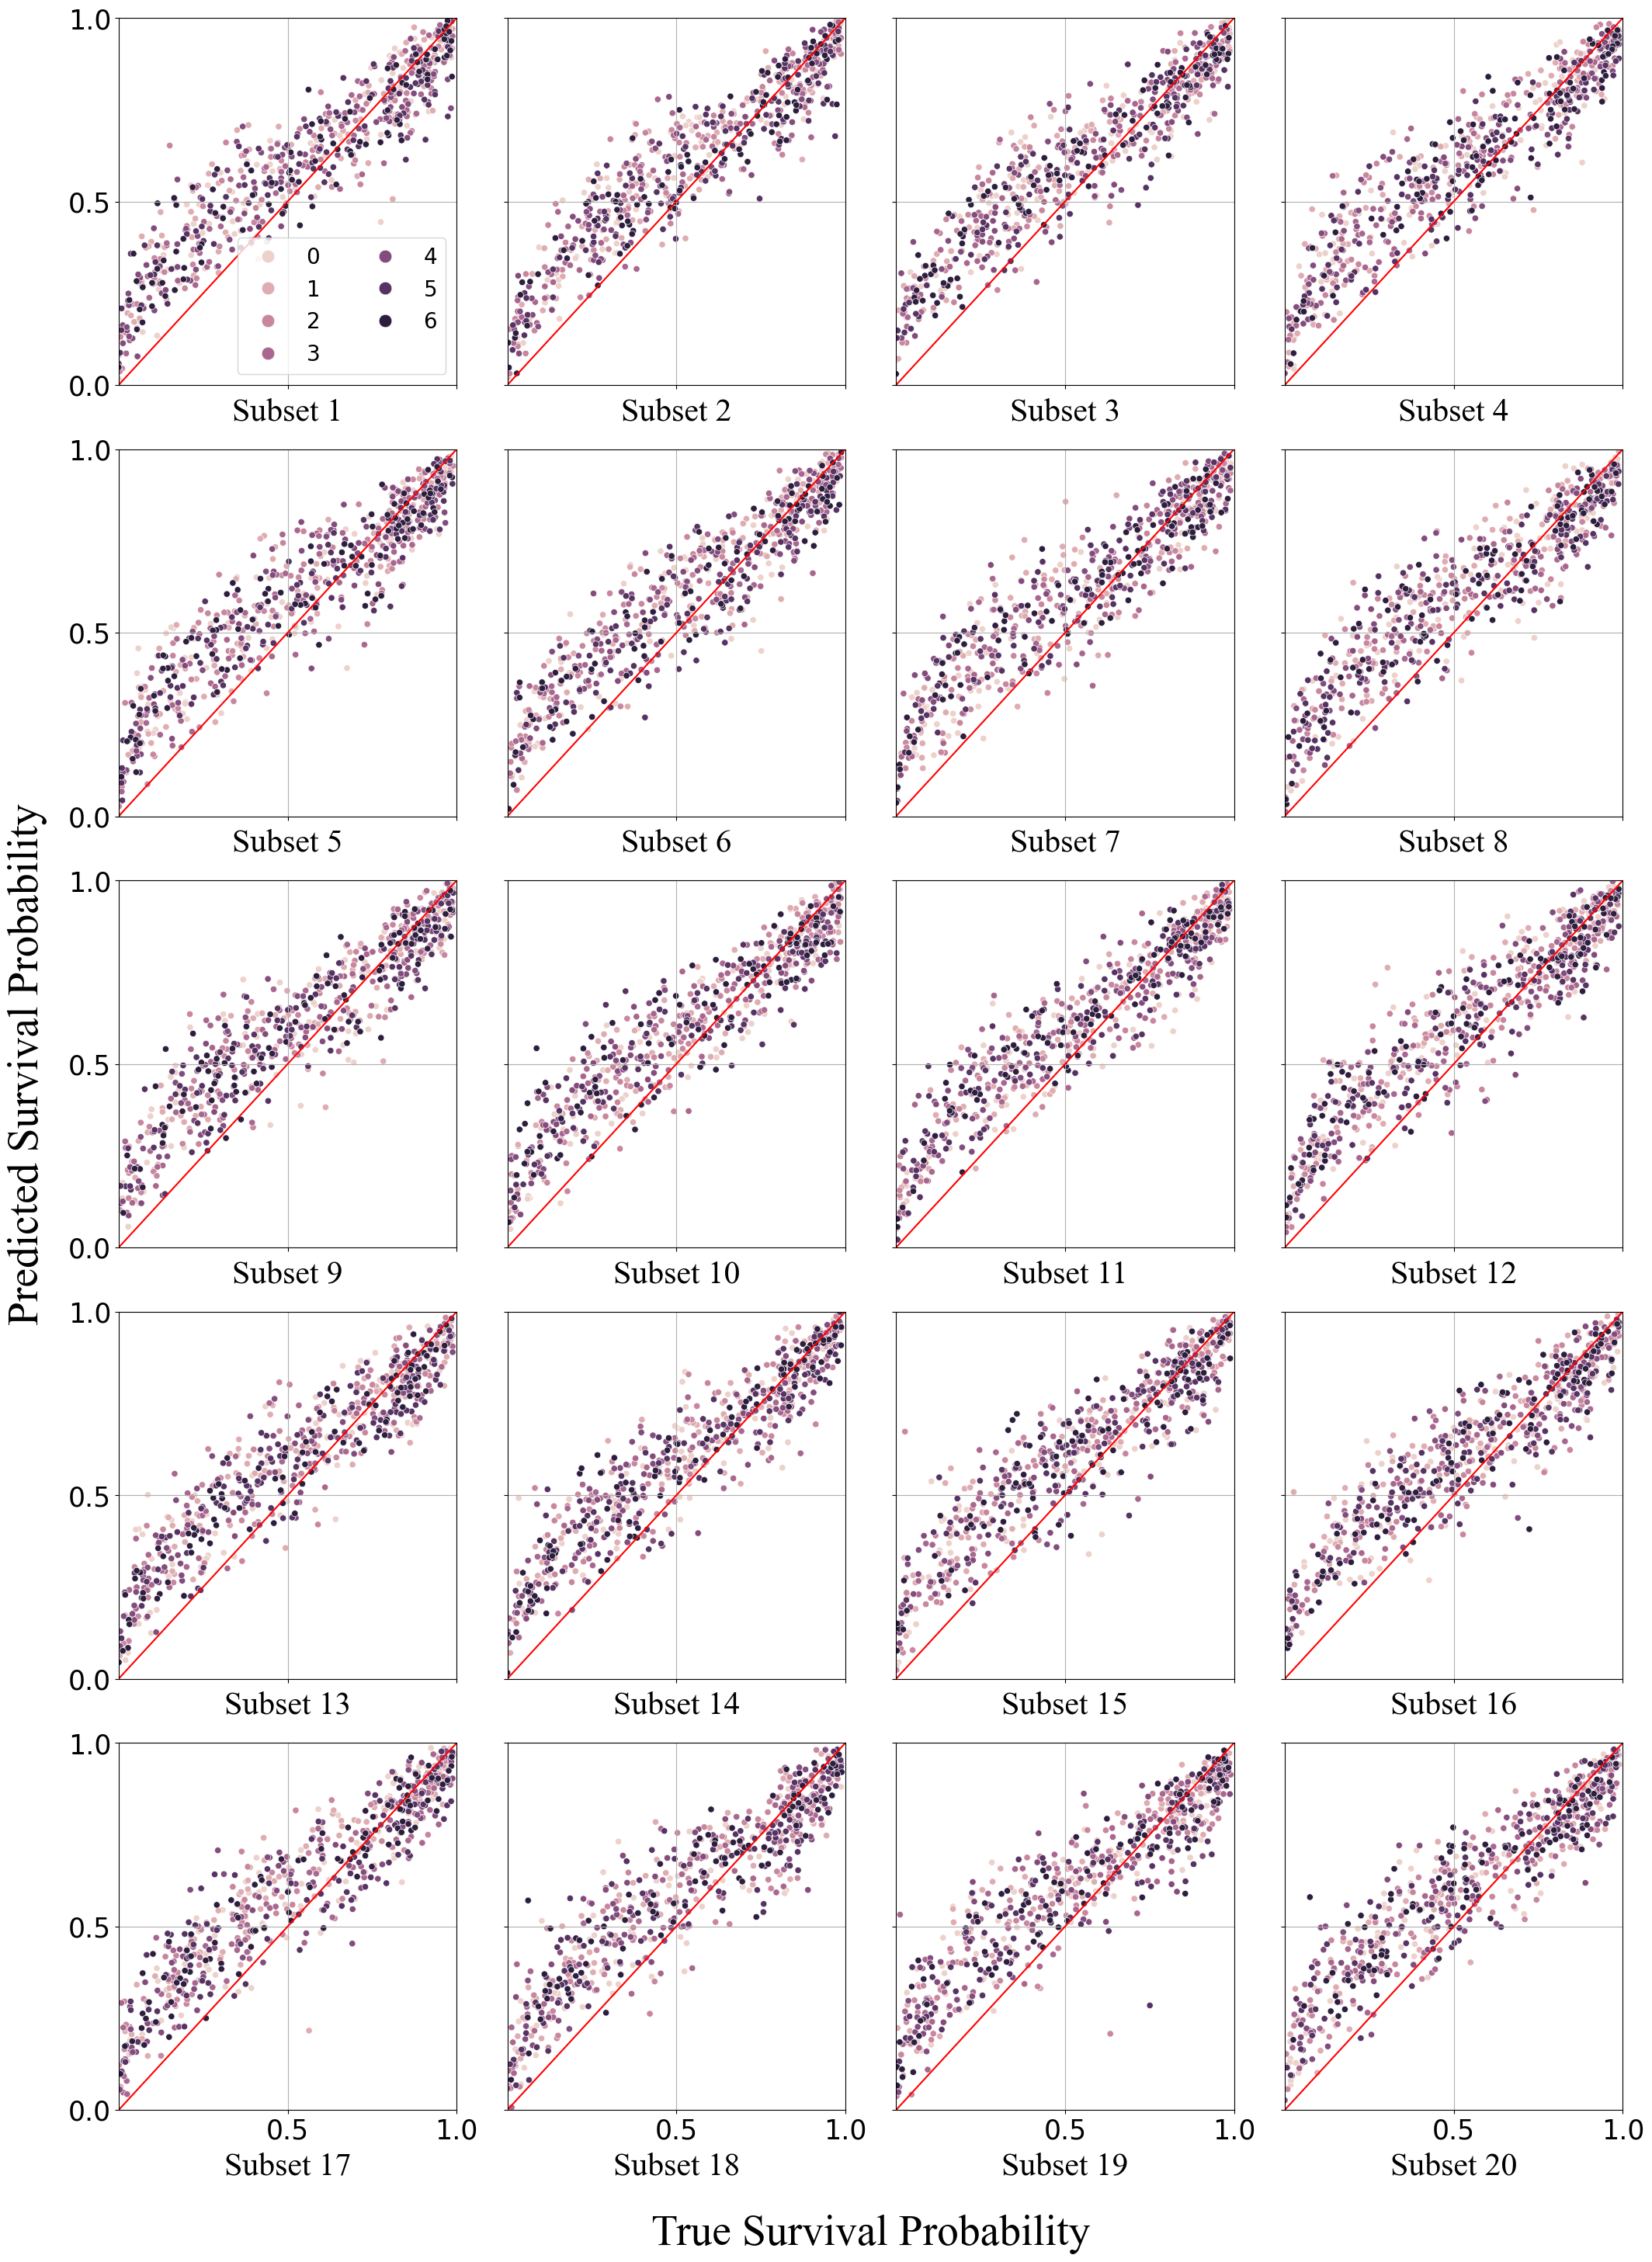

In [17]:
font = {'family': 'Times New Roman',
        'color':  'black',
        'weight': 'normal',
        'size': 30,
        }

title_name = [f'Subset {i+1}' for i in range(20)]
fig, ax = plt.subplots(5,4, sharex=True, sharey=True, figsize=(25,35))
fig.subplots_adjust(wspace=0.15, hspace=0.175)


for i in range(5):
    for j in range(4):
        if (i==0) & (j==0):
            legend=True
        else:
            legend=False
        if i < 4:
            dddddd = EST_SF_TRAIN[4*i+j]
            sns.scatterplot(dddddd, x='true_sf', y='est_sf', hue='true_z', ax=ax[i,j], legend=legend)
            sns.lineplot(x=[0,1], y=[0,1], color='red', ax=ax[i,j])
            if (i==0) & (j==0):
                ax[i,j].legend(fontsize=20, markerscale=2, ncol=2)
            ax[i,j].set_xlabel('', fontsize=25)
            ax[i,j].set_xlim([0,1])
            ax[i,j].set_ylabel('', fontsize=25)
            ax[i,j].set_ylim([0,1])
            ax[i,j].tick_params(axis="x", labelsize=25)
            ax[i,j].tick_params(axis="y", labelsize=25)
            ax[i,j].set_title(title_name[4*i+j], y=0.04, pad=-25, verticalalignment="top", fontdict=font)
            ax[i,j].set_xticks([0.5,1])
            ax[i,j].set_yticks([0,0.5,1])
            # ax[0].set_title(r'(a) Density of $\sigma^2$.', fontdict=font)
            ax[i,j].grid()
        else:
            dddddd = EST_SF_TEST[i-4+j]
            sns.scatterplot(dddddd, x='true_sf', y='est_sf', hue='true_z', ax=ax[i,j], legend=legend)
            sns.lineplot(x=[0,1], y=[0,1], color='red', ax=ax[i,j])
            ax[i,j].set_xlabel('', fontsize=25)
            ax[i,j].set_xlim([0,1])
            ax[i,j].set_ylabel('', fontsize=25)
            ax[i,j].set_ylim([0,1])
            ax[i,j].tick_params(axis="x", labelsize=25)
            ax[i,j].tick_params(axis="y", labelsize=25)
            ax[i,j].set_title(title_name[4*i+j], y=-0.04, pad=-25, verticalalignment="top", fontdict=font)
            # ax[0].set_title(r'(a) Density of $\sigma^2$.', fontdict=font)
            ax[i,j].grid()

fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.xlabel("True Survival Probability", fontsize=40, y=-6, labelpad=80, verticalalignment="top", fontdict=font)
plt.ylabel("Predicted Survival Probability", fontsize=40, x=-5, labelpad=80, verticalalignment="top", fontdict=font)
plt.show()
fig.savefig('Performance across subsets-7.png')

In [28]:
preds_time_stamp = [365*i for i in [1, 5, 9, 13, 17]]
SCORE = []

for k in preds_time_stamp:
    dd_TRAIN = []
    for i in range(16):
        EST_SF_ALL_ITERATIONS = []
        for ii in range(data_train[i].shape[0]):
            est_sf, true_sf = Agg_sf_train(ii,i,k)
            EST_SF_ALL_ITERATIONS.append(est_sf)
        EST_SF_ALL_ITERATIONS = np.array(EST_SF_ALL_ITERATIONS)
        EST_SF_ALL_ITERATIONS = pd.DataFrame(EST_SF_ALL_ITERATIONS)
        EST_SF_ALL_ITERATIONS['y'] = data_train[i]['y']
        EST_SF_ALL_ITERATIONS['C'] = data_train[i]['C']
        dd_TRAIN.append(EST_SF_ALL_ITERATIONS)
    dd_TRAIN = pd.concat(dd_TRAIN, ignore_index=True)
    dd_TRAIN.loc[(dd_TRAIN['C'] == 1) & (dd_TRAIN['y'] >= k),'C'] = 0
    dd_TRAIN = dd_TRAIN.replace(np.nan, 0)
    y_train = Surv.from_arrays(dd_TRAIN['C'], dd_TRAIN['y'])
    y_train_prc = dd_TRAIN[((dd_TRAIN['y'] <= k) & (dd_TRAIN['C'] == 1))|(dd_TRAIN['C'] == 0) & (dd_TRAIN['y'] >= k)]
    dd_TEST = []
    for i in range(4):
        EST_SF_ALL_TEST = []
        for ii in range(data_test[i].shape[0]):
            est_sf, true_sf = Agg_sf_test(ii,i,k)
            EST_SF_ALL_TEST.append(est_sf)
        EST_SF_ALL_TEST = np.array(EST_SF_ALL_TEST)
        EST_SF_ALL_TEST = pd.DataFrame(EST_SF_ALL_TEST)
        EST_SF_ALL_TEST['y'] = data_test[i]['y']
        EST_SF_ALL_TEST['C'] = data_test[i]['C']
        dd_TEST.append(EST_SF_ALL_TEST)
    dd_TEST = pd.concat(dd_TEST, ignore_index=True)
    dd_TEST = dd_TEST.replace(np.nan, 0)
    dd_TEST = dd_TEST[dd_TEST['y']<=dd_TRAIN['y'].max()]
    dd_TEST.loc[(dd_TEST['C'] == 1) & (dd_TEST['y'] >= k),'C'] = 0
    y_test = Surv.from_arrays(dd_TEST['C'], dd_TEST['y'])
    y_test_prc = dd_TEST[((dd_TEST['y'] <= k) & (dd_TEST['C'] == 1))|(dd_TEST['C'] == 0) & (dd_TEST['y'] >= k)]
    AUROC_train = []
    AUROC_test = []
    AUPRC_train = []
    AUPRC_test = []
    for t in range(50):
        auroc_train = cumulative_dynamic_auc(y_train, y_train, 1-dd_TRAIN.iloc[:,t], k)[0][0]
        auroc_test = cumulative_dynamic_auc(y_train, y_test, 1-dd_TEST.iloc[:,t],k)[0][0]
        precision_train, recall_train, thresholds_train = metrics.precision_recall_curve(y_train_prc['C'], y_train_prc.iloc[:,t])
        precision_test, recall_test, thresholds_test = metrics.precision_recall_curve(y_test_prc['C'], y_test_prc.iloc[:,t])
        prc_train = pd.DataFrame({'precision_train': precision_train, 'recall_train': recall_train})
        prc_test = pd.DataFrame({'precision_test': precision_test, 'recall_test': recall_test})
        prc_train.sort_values(by='precision_train', inplace=True)
        prc_test.sort_values(by='precision_test', inplace=True)
        auprc_train = metrics.auc(recall_train, precision_train)
        auprc_test = metrics.auc(recall_test, precision_test)
        AUROC_train.append(auroc_train)
        AUROC_test.append(auroc_test)
        AUPRC_train.append(auprc_train)
        AUPRC_test.append(auprc_test)
    auroc_k_train = np.array(AUROC_train).mean()
    auroc_k_test = np.array(AUROC_test).mean()
    auprc_k_train = np.array(AUPRC_train).mean()
    auprc_k_test = np.array(AUPRC_test).mean()
    SCORE.append([auroc_k_train, auroc_k_test, auprc_k_train, auprc_k_test])
SCORE = pd.DataFrame(SCORE, columns=['AUROC-TRAIN', 'AUROC-TEST', 'AUPRC-TRAIN','AUPRC-TEST'])
print(SCORE)

   AUROC-TRAIN  AUROC-TEST  AUPRC-TRAIN  AUPRC-TEST
0     0.979876    0.975467     0.025520    0.023593
1     0.998450    0.998084     0.157129    0.156345
2     0.996783    0.995631     0.357190    0.355182
3     0.995219    0.993886     0.640825    0.652152
4     0.983927    0.987032     0.871515    0.874339


In [21]:
pred_sf_cluster = pd.concat([Pred_sf_train, Pred_sf_test], ignore_index=True)
pred_sf_cluster = pred_sf_cluster.mean(axis=1)
pred_sf_cluster.to_csv('pred_sf_cluster.csv')

In [22]:
sf_unit = pd.read_csv('pred_sf_unit.csv', index_col=0)
sf_unit = sf_unit.iloc[:,0].values
sf_cluster = pd.read_csv('pred_sf_cluster.csv', index_col=0)
sf_cluster = sf_cluster.iloc[:,0].values
FULL = pd.concat([Training, Testing], ignore_index=True)
true_sf = FULL['true_sf'].values
true_Z = FULL['Z'].values+1
Comp = pd.DataFrame({'True': true_sf, 'Unit': sf_unit, 'Cluster': sf_cluster, 'cluster': true_Z})
# Comp['CCluster'] = 0.7*Comp['Cluster']+0.3*Comp['True']
for i in range(10):
    Comp.loc[Comp['cluster']==i+1, 'Z'] = f'Cluster {i+1}'

In [23]:
outliers = np.zeros(Comp.shape[0])
outliers[np.arange(0,Comp.shape[0], 100)+99] += 1
Comp['outliers'] = outliers
for i in range(2):
    if i == 0:
        Comp.loc[Comp['outliers'] == i, 'outlier'] = 'No'
        
    else:
        Comp.loc[Comp['outliers'] == i, 'outlier'] = 'Yes'
        # Comp.loc[Comp['outliers'] == i, 'CCluster'] = Comp.loc[Comp['outliers'] == i, 'Cluster']


e:\Python\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
e:\Python\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
e:\Python\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
e:\Python\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', Tru

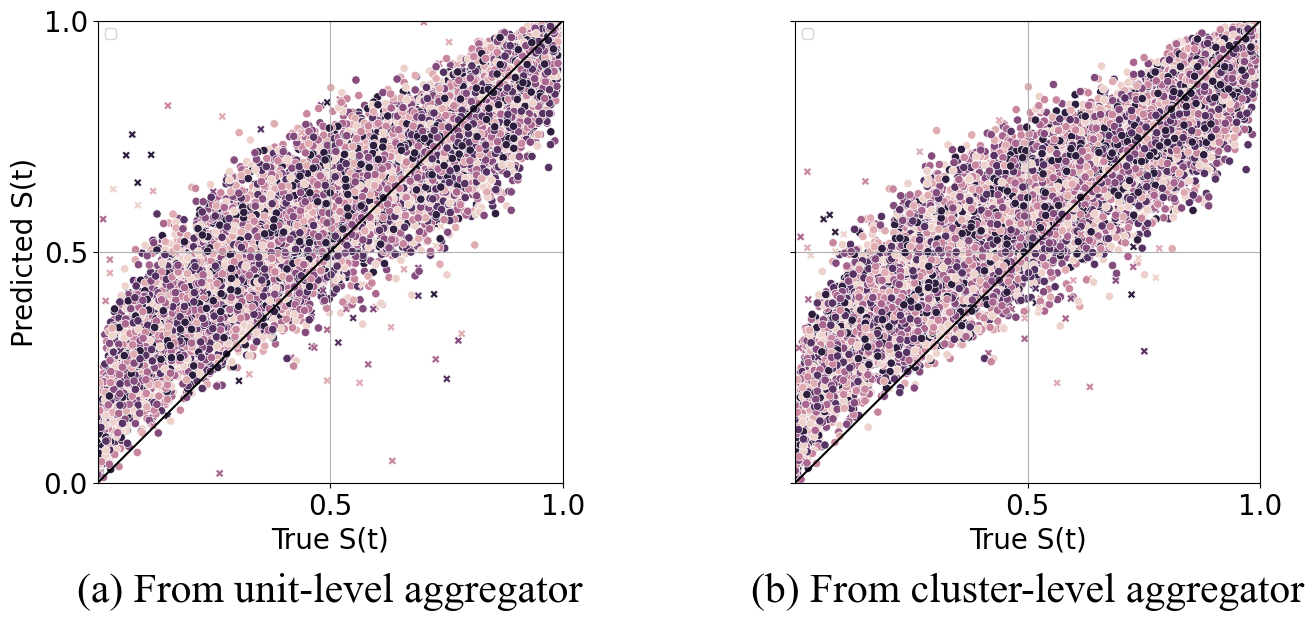

In [24]:
font = {'family': 'Times New Roman',
        'color':  'black',
        'weight': 'normal',
        'size': 30,
        }

title_name = [f'Subset {i+1}' for i in range(20)]
fig, ax = plt.subplots(1,2, sharex=False, sharey=True, figsize=(15,6))
fig.subplots_adjust(wspace=0.5, hspace=0.175)

sns.scatterplot(Comp, x='True', y='Unit', hue='cluster', style='outlier', ax=ax[0])
sns.lineplot(x=[0,1], y=[0,1], color='black', ax=ax[0])
ax[0].set_xlabel('True S(t)', fontsize=20)
ax[0].set_xlim([0,1])
ax[0].set_ylabel('Predicted S(t)', fontsize=20)
ax[0].set_ylim([0,1])
ax[0].tick_params(axis="x", labelsize=20)
ax[0].tick_params(axis="y", labelsize=20)
ax[0].set_title('(a) From unit-level aggregator', y=-0.12, pad=-25, verticalalignment="top", fontdict=font)
ax[0].legend([])
# ax[0].legend(fontsize=15, framealpha=1, markerscale=2)
ax[0].set_xticks([0.5,1])
ax[0].set_yticks([0,0.5,1])
# ax[0].set_title(r'(a) Density of $\sigma^2$.', fontdict=font)
ax[0].grid()


sns.scatterplot(Comp, x='True', y='Cluster', hue='cluster', style='outlier', ax=ax[1])
sns.lineplot(x=[0,1], y=[0,1], color='black', ax=ax[1])
ax[1].set_xlabel('True S(t)', fontsize=20)
ax[1].set_xlim([0,1])
ax[1].set_ylabel('Predicted S(t)', fontsize=20)
ax[1].set_ylim([0,1])
ax[1].tick_params(axis="x", labelsize=20)
ax[1].tick_params(axis="y", labelsize=20)
ax[1].set_title('(b) From cluster-level aggregator', y=-0.12, pad=-25, verticalalignment="top", fontdict=font)
ax[1].legend([])
ax[1].set_xticks([0.5,1])
ax[1].set_yticks([0,0.5,1])
# ax[0].set_title(r'(a) Density of $\sigma^2$.', fontdict=font)
ax[1].grid()


fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
# plt.xlabel("True Survival Probability", fontsize=40, y=-6, labelpad=80, verticalalignment="top", fontdict=font)
# plt.ylabel("Predicted Survival Probability", fontsize=40, x=-5, labelpad=80, verticalalignment="top", fontdict=font)
plt.show()
fig.savefig('Performance across aggregators-9.png')

In [50]:
Comp.to_csv('comp.csv')

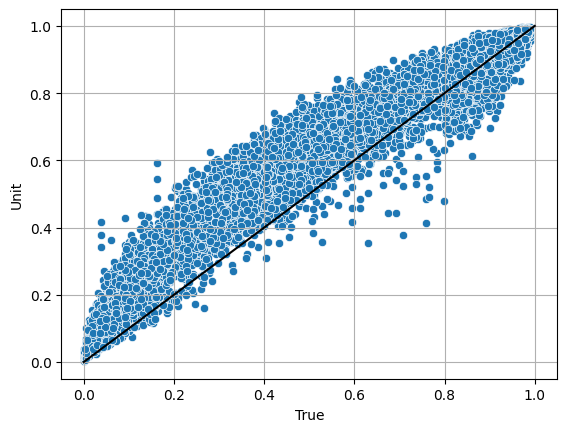

In [95]:
sns.scatterplot(Comp['Unit'])
sns.lineplot(x=[0,1], y=[0,1], color='black')
plt.grid()

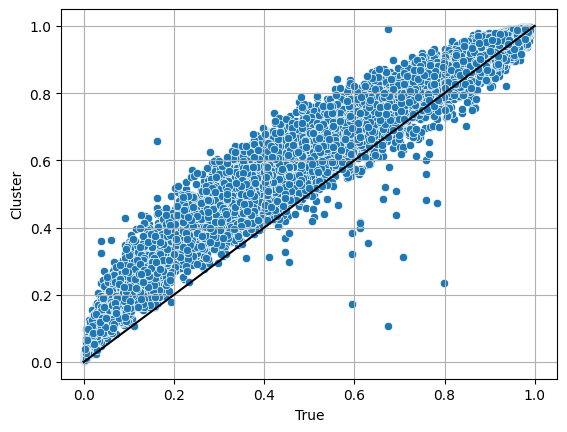

In [96]:
sns.scatterplot(Comp['Cluster'])
sns.lineplot(x=[0,1], y=[0,1], color='black')
plt.grid()